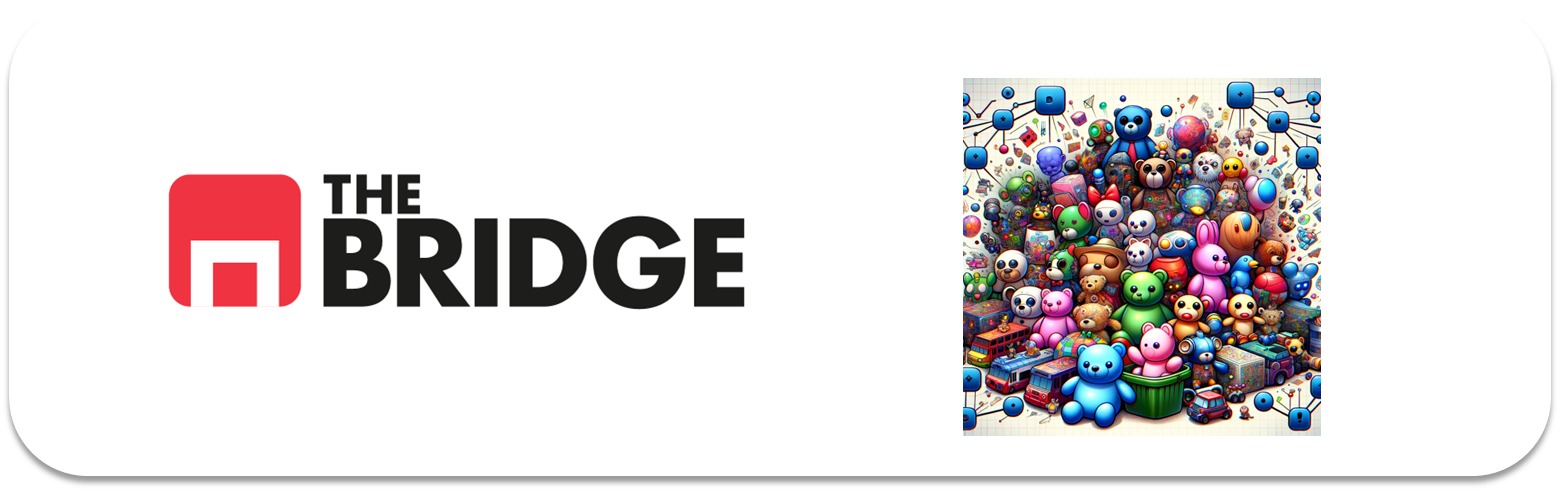

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
from sklearn.ensemble import RandomForestClassifier

from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)


import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [2]:
from sklearn.datasets import fetch_olivetti_faces

# Carga del dataset
olivetti = fetch_olivetti_faces()

# Descripción del dataset
print(olivetti['DESCR'])

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [3]:
# Mostrar target
print("Target:")
print(olivetti['target'])
print(f"\nShape: {olivetti['target'].shape}")

Target:
[ 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  2  2  2  2
  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4
  4  4  5  5  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  7  7
  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  9  9  9  9  9  9
  9  9  9  9 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11
 12 12 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 14 14 14 14
 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16
 16 16 17 17 17 17 17 17 17 17 17 17 18 18 18 18 18 18 18 18 18 18 19 19
 19 19 19 19 19 19 19 19 20 20 20 20 20 20 20 20 20 20 21 21 21 21 21 21
 21 21 21 21 22 22 22 22 22 22 22 22 22 22 23 23 23 23 23 23 23 23 23 23
 24 24 24 24 24 24 24 24 24 24 25 25 25 25 25 25 25 25 25 25 26 26 26 26
 26 26 26 26 26 26 27 27 27 27 27 27 27 27 27 27 28 28 28 28 28 28 28 28
 28 28 29 29 29 29 29 29 29 29 29 29 30 30 30 30 30 30 30 30 30 30 31 31
 31 31 31 31 31 31 31 31 32 32 32 32 32 32 

In [4]:
# DataFrame con las features + target
df = pd.DataFrame(olivetti['data'])
df['target'] = olivetti['target']

In [5]:
df_ale = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_ale.shape)
df_ale.head()

(400, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3
3,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859,21
4,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405,9


### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

In [6]:
X = df_ale.drop(columns='target')
y = df_ale['target']

# Split 90-10 -> train+val / test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)

# Split 89-11 sobre el 90% -> train / val (80-10 del total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)


print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (320, 4096)
X_val:   (40, 4096)
X_test:  (40, 4096)


### #1.4

Crea los pares X,y para train, validation y test.

In [7]:
# Train
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

# Validation
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")

# Test
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (320, 4096)
y_train: (320,)
X_val:   (40, 4096)
y_val:   (40,)
X_test:  (40, 4096)
y_test:  (40,)


Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [8]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

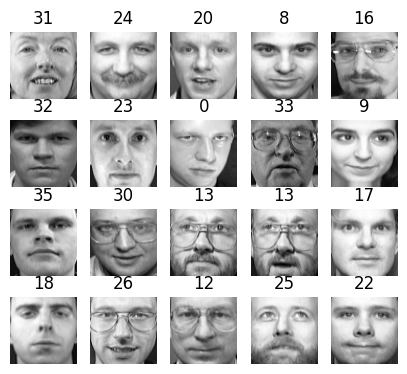

In [9]:
# Visualizamos las primeras 20 imágenes de train
plot_faces(X_train.iloc[:20].values, y_train.iloc[:20].values)

### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [10]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(221)

### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

In [11]:

silhouette_scores = {}

for k in range(5, 151, 5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_pca)
    score = silhouette_score(X_train_pca, labels)
    silhouette_scores[k] = score
    print(f"Para k={k} | silohuette={score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nMejor k: {best_k} | Mejor Silhouette score: {silhouette_scores[best_k]:.4f}")

Para k=5 | silohuette=0.1088
Para k=10 | silohuette=0.1040
Para k=15 | silohuette=0.1020
Para k=20 | silohuette=0.1082
Para k=25 | silohuette=0.1183
Para k=30 | silohuette=0.1243
Para k=35 | silohuette=0.1534
Para k=40 | silohuette=0.1497
Para k=45 | silohuette=0.1570
Para k=50 | silohuette=0.1714
Para k=55 | silohuette=0.1770
Para k=60 | silohuette=0.1783
Para k=65 | silohuette=0.1889
Para k=70 | silohuette=0.1882
Para k=75 | silohuette=0.1936
Para k=80 | silohuette=0.1955
Para k=85 | silohuette=0.1989
Para k=90 | silohuette=0.1976
Para k=95 | silohuette=0.1966
Para k=100 | silohuette=0.1957
Para k=105 | silohuette=0.2007
Para k=110 | silohuette=0.1989
Para k=115 | silohuette=0.1893
Para k=120 | silohuette=0.1925
Para k=125 | silohuette=0.1968
Para k=130 | silohuette=0.2020
Para k=135 | silohuette=0.1970
Para k=140 | silohuette=0.1983
Para k=145 | silohuette=0.1966
Para k=150 | silohuette=0.1971

Mejor k: 130 | Mejor Silhouette score: 0.2020


### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

k=  5 | inertia=17074.91
k= 10 | inertia=14760.67
k= 15 | inertia=13501.86
k= 20 | inertia=12438.46
k= 25 | inertia=11331.73
k= 30 | inertia=10486.67
k= 35 | inertia=9716.96
k= 40 | inertia=9142.74
k= 45 | inertia=8589.32
k= 50 | inertia=8013.91
k= 55 | inertia=7575.40
k= 60 | inertia=7113.36
k= 65 | inertia=6737.89
k= 70 | inertia=6412.48
k= 75 | inertia=6052.83
k= 80 | inertia=5784.68
k= 85 | inertia=5451.21
k= 90 | inertia=5212.12
k= 95 | inertia=4985.23
k=100 | inertia=4738.54
k=105 | inertia=4512.06
k=110 | inertia=4260.26
k=115 | inertia=4073.12
k=120 | inertia=3869.55
k=125 | inertia=3668.69
k=130 | inertia=3431.16
k=135 | inertia=3295.28
k=140 | inertia=3095.32
k=145 | inertia=2931.05
k=150 | inertia=2769.72


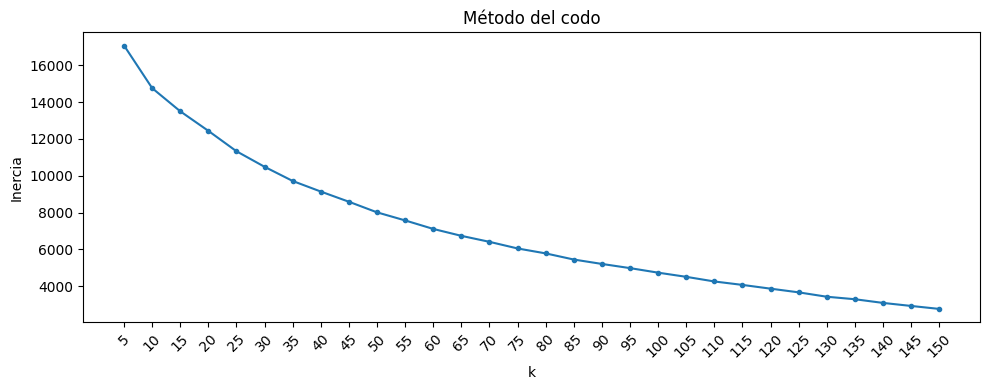

In [12]:
inertias = {}

for k in range(5, 151, 5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_pca)
    inertias[k] = kmeans.inertia_
    print(f"k={k:3d} | inertia={kmeans.inertia_:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), marker='o', markersize=3)
plt.xlabel("k")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(range(5, 151, 5), rotation=45)
plt.tight_layout()
plt.show()

La curva de inercia no muestra un codo claro, es una bajada continua y suave sin ningún punto de inflexión evidente.  
Esto no refuerza ni contradice el k=130 obtenido con silhouette.

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [13]:
best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_model.fit_predict(X_train_pca)

array([ 90,  23,   7,  40,  15,  95,  25, 106, 102,  72,  63,  41,  14,
        14,   4,  34,  11,  50,  10,  10,  82,  23,  99,  32,  29,   0,
        86, 107,  12,  14,  27,  19, 128,  33,  19, 126,  86,  45,  56,
        13,  88,  51,  54,  76,  46,  31,  97,  27,  69,  94,  67,  11,
        47,  80, 122,  21,  83,  91,  93,  46,  61, 109, 121,  41, 120,
        84, 100,  12,  95, 110,   3,  57, 112,   4,  36,  13,  47,  62,
       115,  38,  73,  11,  43,  64,  88,  38, 116,  70,  17,  41,  15,
         9,  28, 105,  31, 126,  13,  45,  80, 105,  49,  91,  12,  52,
        65,   6,  99,  36,  37,  94,  64,  40,  20,   9,  86,  47, 127,
        55,  63,  51,  92,  68,  15,  45,  53,   2,  11,  55,  16,  36,
        43,  61,  22,   4,   0, 121,  94,  25,  24,  27, 117,  37,  54,
        50,  65,  13,  18,  23,  31,  52, 109,  11, 111,  48,  75, 101,
        54,  40,  67, 117,   3,  53,   6,  55,  82,  72,  74, 123,  98,
        80,  15,   4,   4,  21,  89,  44,   1,  84,  85, 111,   

### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?


Clúster 0 (2 imágenes):


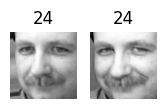


Clúster 1 (4 imágenes):


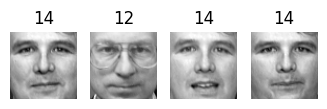


Clúster 2 (3 imágenes):


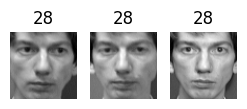


Clúster 3 (3 imágenes):


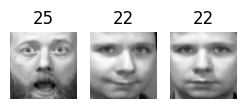


Clúster 4 (7 imágenes):


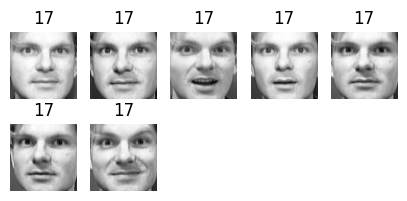


Clúster 5 (3 imágenes):


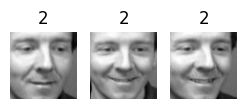


Clúster 6 (3 imágenes):


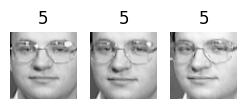


Clúster 7 (2 imágenes):


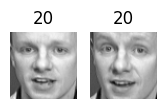


Clúster 8 (3 imágenes):


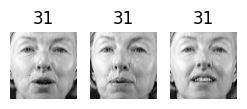


Clúster 9 (4 imágenes):


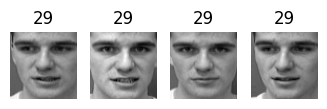

In [14]:
cluster_labels = best_model.labels_

for cluster_id in range(10):
    mask = cluster_labels == cluster_id
    faces = X_train.values[mask]
    labels = y_train.values[mask]
    print(f"\nClúster {cluster_id} ({mask.sum()} imágenes):")
    plot_faces(faces, labels)

La tendencia general es que le modelo agrupa correctamente por identidad en la mayoría de los clústeres, con algún fallo puntual (clúster 1 y clúster 3).

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

In [15]:
rf = RandomForestClassifier(n_estimators=150, random_state=42)

rf.fit(X_train_pca, y_train)

score = rf.score(X_val_pca, y_val)
print(f"Accuracy en validación: {score:.4f}")

Accuracy en validación: 0.9750


c:\Users\user\Documents\GitHub\toolbox_ml\venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

In [16]:
# Transformación: distancias a los 130 centroides
X_train_reduced = best_model.transform(X_train_pca)
X_val_reduced = best_model.transform(X_val_pca)
X_test_reduced = best_model.transform(X_test_pca)

print(f"X_train_reduced: {X_train_reduced.shape}")
print(f"X_val_reduced:   {X_val_reduced.shape}")
print(f"X_test_reduced:  {X_test_reduced.shape}")

# RandomForest sobre el espacio reducido
rf_reduced = RandomForestClassifier(n_estimators=150, random_state=42)
rf_reduced.fit(X_train_reduced, y_train)

score_reduced = rf_reduced.score(X_val_reduced, y_val)
print(f"\nAccuracy en validación (K-Means reduced): {score_reduced:.4f}")

X_train_reduced: (320, 130)
X_val_reduced:   (40, 130)
X_test_reduced:  (40, 130)

Accuracy en validación (K-Means reduced): 0.8750


c:\Users\user\Documents\GitHub\toolbox_ml\venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)

In [25]:
accuracies = {}

for k in range(5, 150, 5):
    # K_means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    X_train_red = kmeans.fit_transform(X_train_pca)
    X_val_red = kmeans.transform(X_val_pca)

    # RandomForest
    rf = RandomForestClassifier(n_estimators=150, random_state=42)
    rf.fit(X_train_red, y_train)
    acc = rf.score(X_val_red, y_val)
    accuracies[k] = acc
    print(f"k={k} | accuracy:{acc:.4f}")

best_k_rf = max(accuracies, key=accuracies.get)
print(f"\n Mejor k: {best_k_rf} | Accuracy: {accuracies[best_k_rf]:.4f}")

c:\Users\user\Documents\GitHub\toolbox_ml\venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


k=5 | accuracy:0.4750


c:\Users\user\Documents\GitHub\toolbox_ml\venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


k=10 | accuracy:0.6750


c:\Users\user\Documents\GitHub\toolbox_ml\venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


...

c:\Users\user\Documents\GitHub\toolbox_ml\venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


k=135 | accuracy:0.9250


c:\Users\user\Documents\GitHub\toolbox_ml\venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


k=140 | accuracy:0.9500
k=145 | accuracy:0.9000

 Mejor k: 110 | Accuracy: 0.9500


c:\Users\user\Documents\GitHub\toolbox_ml\venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


## Conclusiones

| Método | Features | Accuracy val |
|---|---|---|
| RandomForest + PCA | 221 componentes | 0.975 |
| RandomForest + K-Means (k=130) | 130 distancias | 0.875 |
| RandomForest + K-Means (k=110) | 110 distancias | 0.950 |

- El k óptimo para clasificación (110) es distinto al k óptimo por silhouette (130): son criterios
diferentes — uno mide calidad del clustering, el otro rendimiento en clasificación supervisada.
- K-Means como reductor de dimensionalidad se acerca bastante a PCA (0.950 vs 0.975)
usando incluso menos features (110 vs 221).
